# Fashion-MNIST 

In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import os

# Create output directory for plots
os.makedirs('output_plots', exist_ok=True)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.21.0
Keras version: 3.14.0


## 1. Load and Preprocess Data

In [2]:
# Load Fashion-MNIST dataset
fashion_mnist = keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape for CNN input (add channel dimension)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

# Class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


## 2. Visualize Sample Images

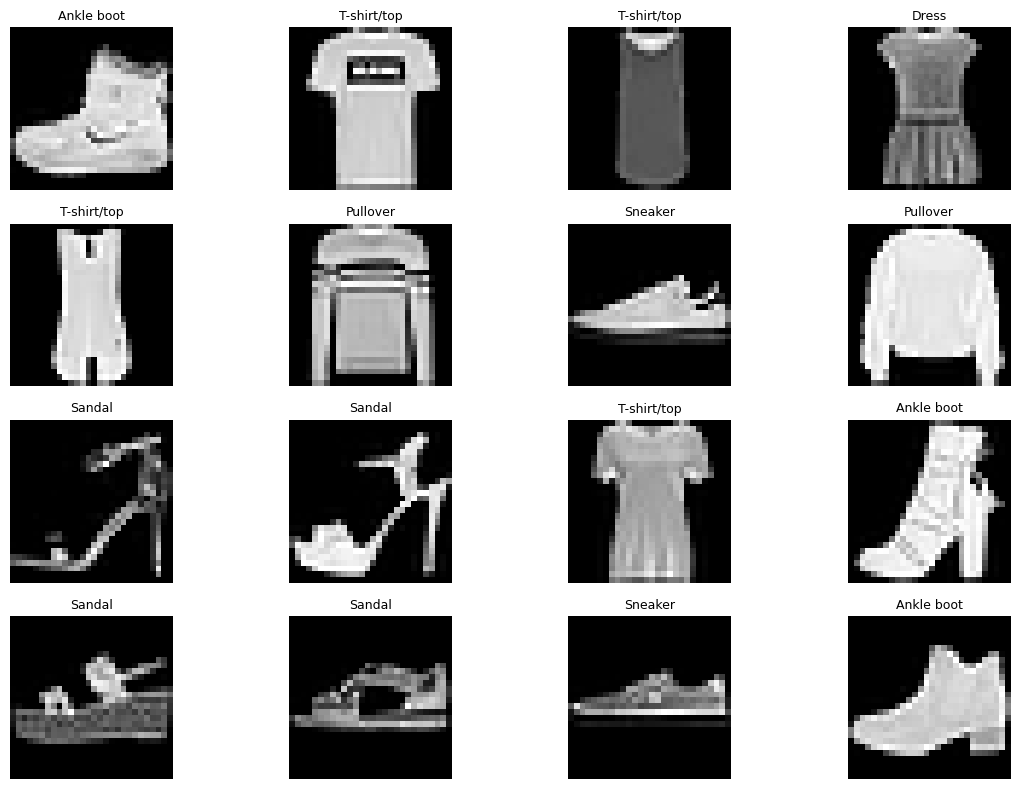

In [3]:
# Plot sample images
plt.figure(figsize=(12, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.savefig('output_plots/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Data Augmentation

To improve generalization and prevent overfitting, we'll use data augmentation techniques.

In [4]:
# Create data augmentation generator
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.1  # 10% of training data for validation
)

# Split training data into train and validation
val_split = 0.1
val_size = int(len(X_train) * val_split)
X_val = X_train[:val_size]
y_val = y_train[:val_size]
X_train_aug = X_train[val_size:]
y_train_aug = y_train[val_size:]

print(f"Training samples: {len(X_train_aug)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

Training samples: 54000
Validation samples: 6000
Test samples: 10000


## 4. Build Custom CNN Architecture

Architecture design:
- **Conv Block 1**: 64 filters (3x3) + BatchNormalization + ReLU + MaxPooling
- **Conv Block 2**: 128 filters (3x3) + BatchNormalization + ReLU + MaxPooling
- **Conv Block 3**: 256 filters (3x3) + BatchNormalization + ReLU + MaxPooling
- **Flatten + Dense**: 512 neurons + BatchNormalization + ReLU + Dropout(0.5)
- **Output Dense**: 10 neurons + Softmax

Techniques used:
- Batch Normalization for faster training and regularization
- Dropout to prevent overfitting
- L2 regularization on dense layers
- Max Pooling for spatial downsample

In [5]:
def create_model():
    model = models.Sequential([
        # First Convolutional Block
        layers.Conv2D(64, (3, 3), padding='same', input_shape=(28, 28, 1)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Second Convolutional Block
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Third Convolutional Block
        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Flatten and Dense Layers
        layers.Flatten(),
        layers.Dense(512, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        
        # Output Layer
        layers.Dense(128, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        
        layers.Dense(10, activation='softmax')
    ])
    
    return model

# Create and display model summary
model = create_model()
model.summary()

d:\programming\python\hw\goit-ds-hw-11\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,806,410 (6.89 MB)

 Trainable params: 1,803,850 (6.88 MB)

 Non-trainable params: 2,560 (10.00 KB)

## 5. Compile Model with Optimal Hyperparameters

In [6]:
# Compile model with Adam optimizer and learning rate scheduling
initial_lr = 0.001

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=initial_lr),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


## 6. Setup Callbacks

In [7]:
# Learning Rate Reducer on Plateau
lr_reducer = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Early Stopping to prevent overfitting
early_stopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

# Model Checkpoint to save best model
model_checkpoint = callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("Callbacks configured!")

Callbacks configured!


## 7. Train the Model

In [ ]:
# Training hyperparameters
EPOCHS = 50
BATCH_SIZE = 64

# Train the model
history = model.fit(
    X_train_aug, y_train_aug,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[lr_reducer, early_stopping, model_checkpoint],
    verbose=1
)

Epoch 1/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.7353 - loss: 1.5980
Epoch 1: val_accuracy improved from None to 0.89500, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 105s 120ms/step - accuracy: 0.8139 - loss: 1.1583 - val_accuracy: 0.8950 - val_loss: 0.6288 - learning_rate: 0.0010
Epoch 2/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8785 - loss: 0.6368
Epoch 2: val_accuracy did not improve from 0.89500
844/844 ━━━━━━━━━━━━━━━━━━━━ 98s 116ms/step - accuracy: 0.8823 - loss: 0.5986 - val_accuracy: 0.8887 - val_loss: 0.5316 - learning_rate: 0.0010
Epoch 3/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.8944 - loss: 0.5351
Epoch 3: val_accuracy improved from 0.89500 to 0.90600, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 231s 221ms/step - accuracy: 0.8950 - loss: 0.5282 - val_accuracy: 0.9060 - val_loss: 0.4

## 8. Plot Training History

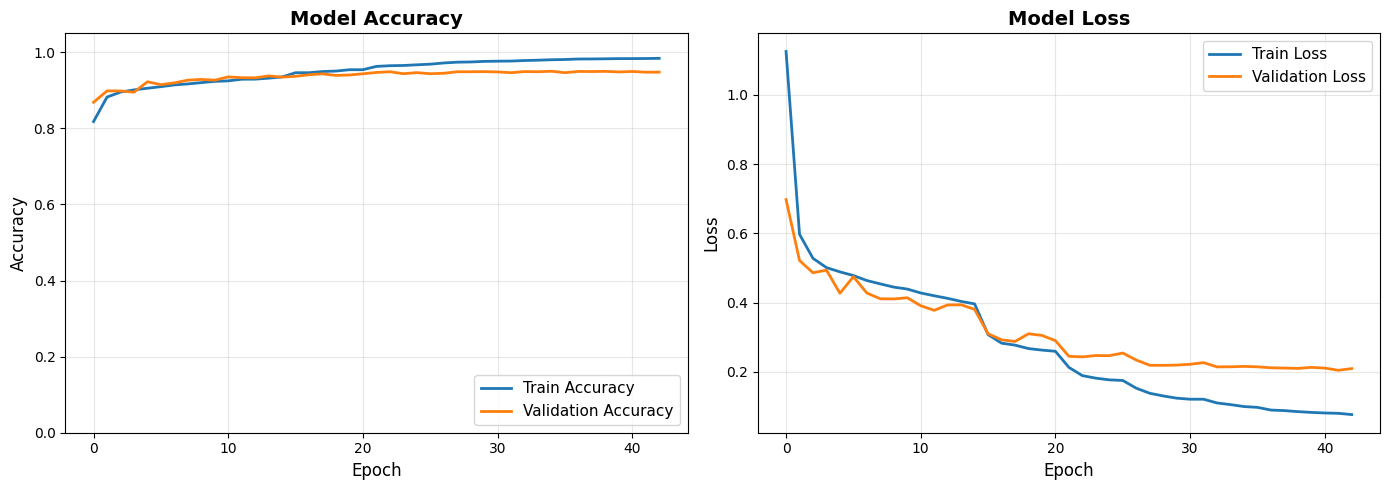


Best Validation Accuracy: 95.03% at epoch 35


In [ ]:
# Plot training & validation accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.05])

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output_plots/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Print best results
best_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_acc) + 1
print(f"\nBest Validation Accuracy: {best_acc*100:.2f}% at epoch {best_epoch}")

## 9. Evaluate on Test Set

In [ ]:
# Load best model
if os.path.exists('best_model.keras'):
    model = keras.models.load_model('best_model.keras')
    print("Loaded best model from checkpoint!")

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Loaded best model from checkpoint!

Test Accuracy: 94.41%
Test Loss: 0.2449


## 10. Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step


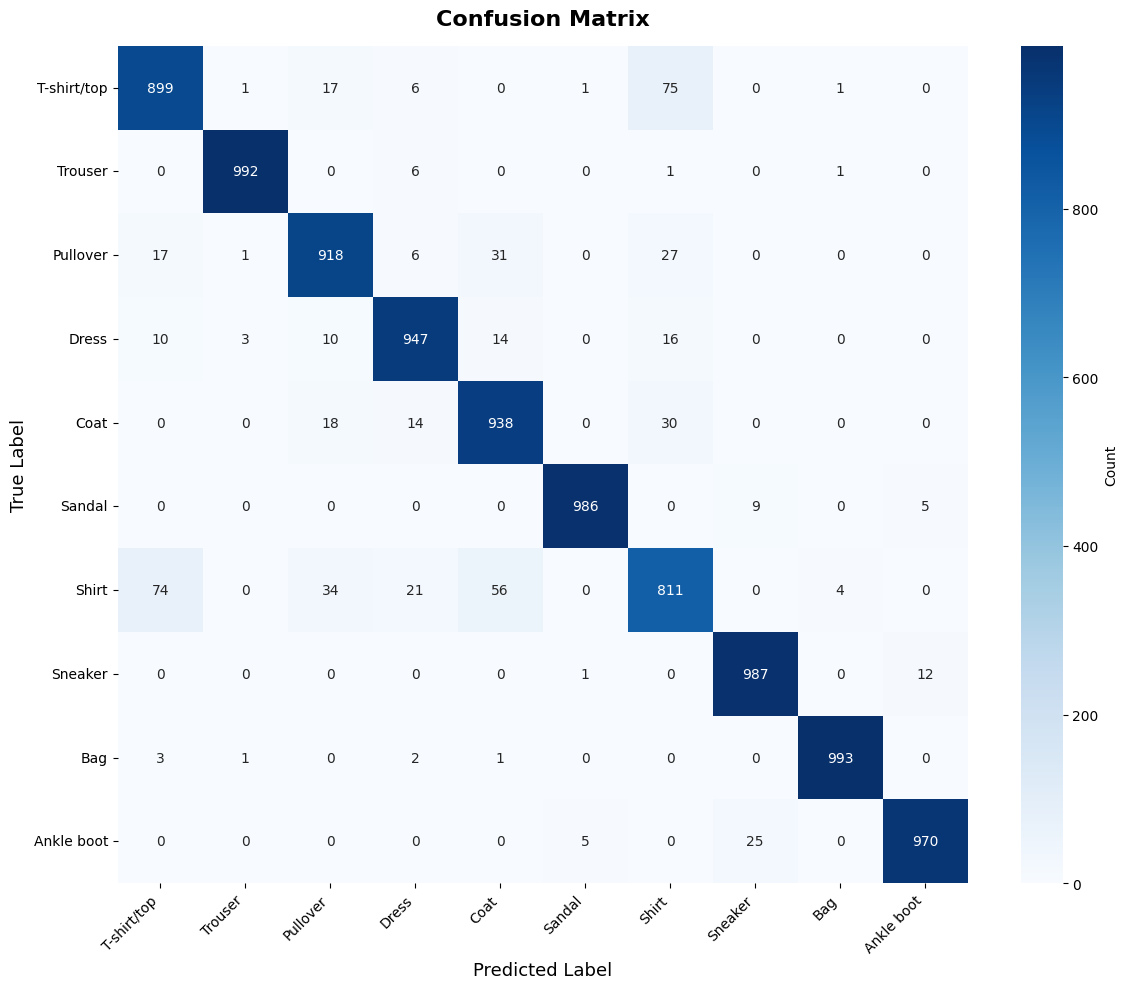


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.90      0.90      0.90      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.92      0.92      0.92      1000
       Dress       0.95      0.95      0.95      1000
        Coat       0.90      0.94      0.92      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.84      0.81      0.83      1000
     Sneaker       0.97      0.99      0.98      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.98      0.97      0.98      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions
y_pred = np.argmax(model.predict(X_test), axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('output_plots/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

## 11. Visualize Predictions on Test Images

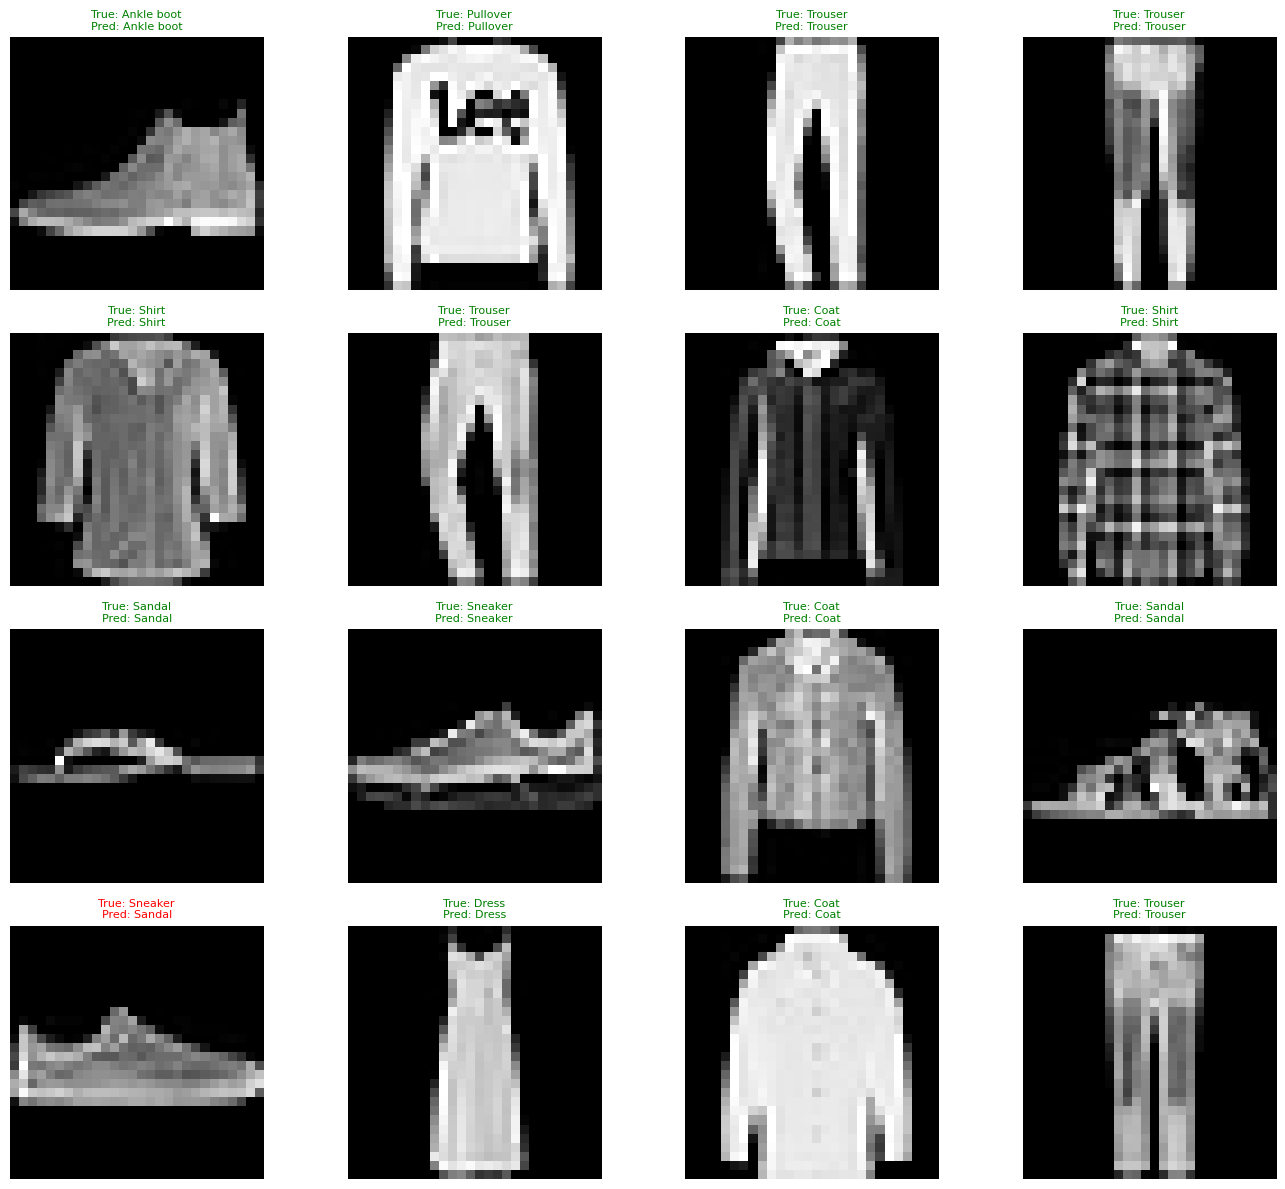

In [ ]:
# Visualize test predictions
def plot_predictions(images, true_labels, pred_labels, num_images=16):
    plt.figure(figsize=(14, 12))
    for i in range(num_images):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap='gray')
        
        # Color code: green for correct, red for incorrect
        color = 'green' if true_labels[i] == pred_labels[i] else 'red'
        plt.title(f"True: {class_names[true_labels[i]]}\nPred: {class_names[pred_labels[i]]}", 
                 color=color, fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.savefig('output_plots/test_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_predictions(X_test, y_test, y_pred)

## 12. Learning Curve Analysis

KeyError: 'lr'

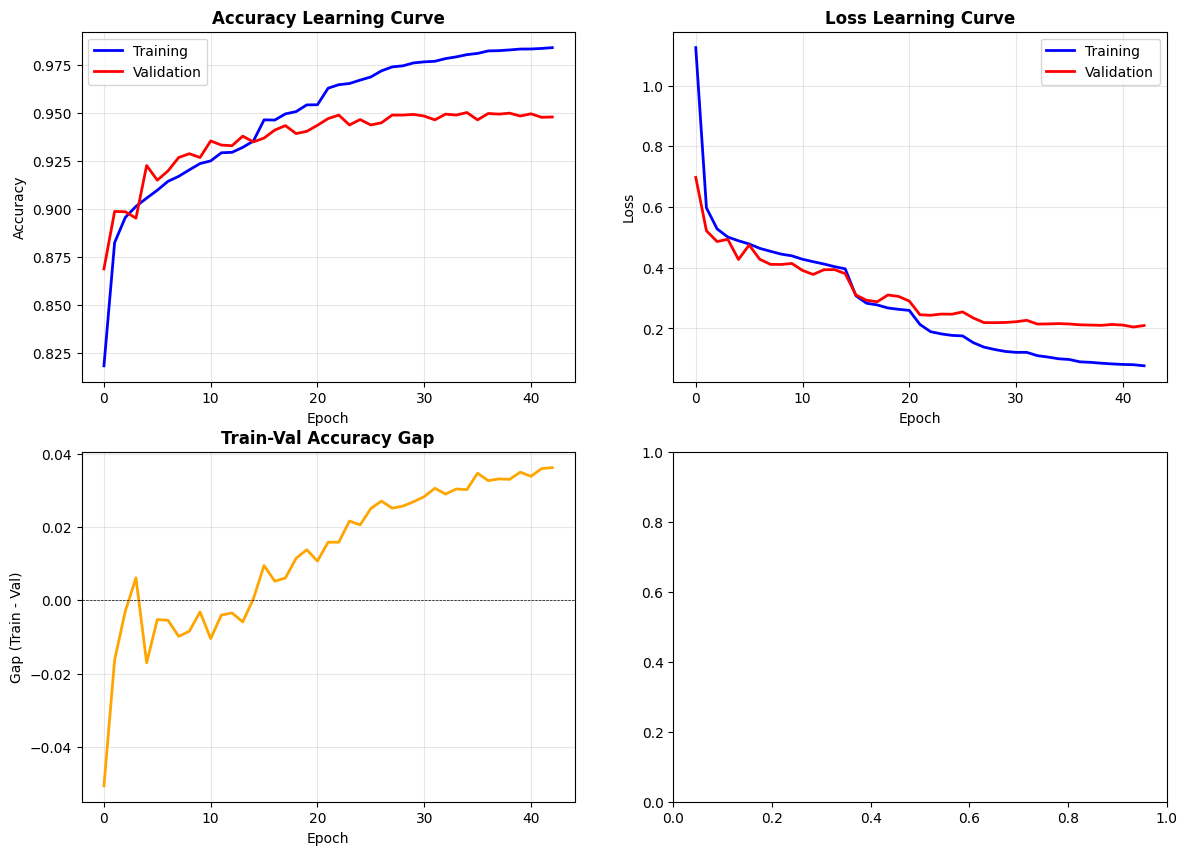

In [ ]:
# Plot learning curves with different metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].plot(history.history['accuracy'], 'b-', label='Training', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], 'r-', label='Validation', linewidth=2)
axes[0, 0].set_title('Accuracy Learning Curve', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss
axes[0, 1].plot(history.history['loss'], 'b-', label='Training', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], 'r-', label='Validation', linewidth=2)
axes[0, 1].set_title('Loss Learning Curve', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Accuracy gap (overfitting indicator)
acc_gap = np.array(history.history['accuracy']) - np.array(history.history['val_accuracy'])
axes[1, 0].plot(acc_gap, 'orange', linewidth=2)
axes[1, 0].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[1, 0].set_title('Train-Val Accuracy Gap', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Gap (Train - Val)')
axes[1, 0].grid(True, alpha=0.3)

# Learning rate schedule
axes[1, 1].plot(history.history['lr'], 'purple', linewidth=2)
axes[1, 1].set_title('Learning Rate Schedule', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output_plots/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Per-Class Accuracy Analysis

In [ ]:
# Calculate per-class accuracy
class_correct = np.diag(cm)
class_total = cm.sum(axis=1)
class_accuracy = class_correct / class_total

# Plot per-class accuracy
plt.figure(figsize=(12, 6))
bars = plt.bar(class_names, class_accuracy*100, color='steelblue', edgecolor='black')
plt.xlabel('Classes', fontsize=13)
plt.ylabel('Accuracy (%)', fontsize=13)
plt.title('Per-Class Accuracy', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim([0, 105])

# Add value labels on bars
for bar, acc in zip(bars, class_accuracy*100):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.axhline(y=test_acc*100, color='red', linestyle='--', linewidth=2, 
           label=f'Overall: {test_acc*100:.2f}%')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('output_plots/per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPer-Class Accuracy:")
for i, (cls, acc) in enumerate(zip(class_names, class_accuracy)):
    print(f"{cls:15s}: {acc*100:5.2f}%")

## 14. Model Architecture Summary

In [ ]:
# Save model architecture visualization
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='output_plots/model_architecture.png', 
           show_shapes=True, show_layer_names=True, dpi=150)
print("Model architecture saved!")

print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print(f"Total Parameters: {model.count_params():,}")
print("="*60)